# My First Notebook

This is a basic Jupyter Notebook.

In [7]:
pip install pandas numpy matplotlib seaborn scikit-learn

  Obtaining dependency information for matplotlib from https://files.pythonhosted.org/packages/fd/14/baad3222f424b19ce6ad243c71de1ad9ec6b2e4eb1e458a48fdc6d120401/matplotlib-3.10.8-cp311-cp311-macosx_11_0_arm64.whl.metadata
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 kB 1.5 MB/s eta 0:00:00
  Obtaining dependency information for seaborn from https://files.pythonhosted.org/packages/83/11/00d3c3dfc25ad54e731d91449895a79e4bf2384dc3ac01809010ba88f6d5/seaborn-0.13.2-py3-none-any.whl.metadata
  Obtaining dependency information for contourpy>=1.0.1 from https://files.pythonhosted.org/packages/0d/44/c4b0b6095fef4dc9c420e041799591e3b63e9619e3044f7f4f6c21c0ab24/contourpy-1.3.3-cp311-cp311-macosx_11_0_arm64.whl.metadata
  Obtaining dependency information for cycler>=0.10 from https://files.pythonhosted.org/packages/e7/05/c19819d5e3d95294a6f5947fb9b9629efb316b96de511b418c53d245aae6/cycler-0.12.1-py3-none-any.whl.metadata
  Obtaining dependency information for fonttools>=4.22.0 from http

In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
warnings.filterwarnings('ignore')

In [9]:
df = pd.read_csv("sales_history.csv")

print("Shape:", df.shape)
print("\nColumn types:\n", df.dtypes)
print("\nFirst 5 rows:\n", df.head())
print("\nBasic stats:\n", df.describe())

Shape: (42625, 5)

Column types:
 product_id    int64
year          int64
month         int64
day           int64
sku_sold      int64
dtype: object

First 5 rows:
    product_id  year  month  day  sku_sold
0           0  2021      6   25       624
1           1  2021     10   25       876
2           2  2021      2    9       579
3           3  2021      1   25       366
4           3  2021      1   30       361

Basic stats:
          product_id          year         month           day      sku_sold
count  42625.000000  42625.000000  42625.000000  42625.000000  42625.000000
mean     282.919789   2019.484012      5.976258     15.756106     22.814780
std      242.229354      1.116431      3.432553      8.781930     48.629637
min        0.000000   2017.000000      1.000000      1.000000      0.000000
25%       63.000000   2018.000000      3.000000      8.000000      3.000000
50%      224.000000   2019.000000      5.000000     16.000000      9.000000
75%      525.000000   2020.000000    

In [10]:
df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

print("Date range:", df['date'].min(), "→", df['date'].max())
print("Total days spanned:", (df['date'].max() - df['date'].min()).days)
print("Unique products:", df['product_id'].nunique())
print("Total records:", len(df))

Date range: 2017-12-25 00:00:00 → 2021-12-24 00:00:00
Total days spanned: 1460
Unique products: 1027
Total records: 42625


In [11]:
print("Missing values:\n", df.isnull().sum())
print("\nZero sales records:", (df['sku_sold'] == 0).sum())
print("Zero sales %:", round((df['sku_sold'] == 0).mean() * 100, 2), "%")

Missing values:
 product_id    0
year          0
month         0
day           0
sku_sold      0
date          0
dtype: int64

Zero sales records: 441
Zero sales %: 1.03 %


In [12]:
dupes = df.duplicated(subset=['product_id', 'year', 'month', 'day'], keep=False)
print("Duplicate records:", dupes.sum())
print("\nSample duplicates:")
print(df[dupes].sort_values(['product_id', 'date']).head(12))

Duplicate records: 108

Sample duplicates:
       product_id  year  month  day  sku_sold       date
20225         315  2020      9   10         1 2020-09-10
20939         315  2020      9   10         1 2020-09-10
18922         315  2020      9   17         1 2020-09-17
20256         315  2020      9   17         1 2020-09-17
18851         315  2020      9   21         2 2020-09-21
20281         315  2020      9   21         1 2020-09-21
18852         315  2020      9   23         2 2020-09-23
21231         315  2020      9   23         0 2020-09-23
20334         315  2020      9   29         1 2020-09-29
20958         315  2020      9   29         1 2020-09-29
20460         315  2020     10   19         1 2020-10-19
21258         315  2020     10   19         0 2020-10-19


In [13]:
df_clean = (
    df.groupby(['product_id', 'date'], as_index=False)['sku_sold']
    .sum()
)

print("Records before:", len(df))
print("Records after dedup:", len(df_clean))

Records before: 42625
Records after dedup: 42571


In [14]:
df_clean['year']        = df_clean['date'].dt.year
df_clean['month']       = df_clean['date'].dt.month
df_clean['day']         = df_clean['date'].dt.day
df_clean['day_of_week'] = df_clean['date'].dt.dayofweek      # 0=Mon, 6=Sun
df_clean['week_of_year']= df_clean['date'].dt.isocalendar().week.astype(int)
df_clean['quarter']     = df_clean['date'].dt.quarter
df_clean['is_weekend']  = df_clean['day_of_week'].isin([5, 6]).astype(int)

print(df_clean[['date','year','month','day_of_week','week_of_year','is_weekend']].head(10))

        date  year  month  day_of_week  week_of_year  is_weekend
0 2020-06-23  2020      6            1            26           0
1 2020-09-17  2020      9            3            38           0
2 2020-12-16  2020     12            2            51           0
3 2021-06-25  2021      6            4            25           0
4 2019-08-26  2019      8            0            35           0
5 2019-09-09  2019      9            0            37           0
6 2019-09-10  2019      9            1            37           0
7 2019-09-11  2019      9            2            37           0
8 2019-09-13  2019      9            4            37           0
9 2020-01-02  2020      1            3             1           0


In [15]:
dow_map = {0:'Mon', 1:'Tue', 2:'Wed', 3:'Thu', 4:'Fri', 5:'Sat', 6:'Sun'}
dow_counts = df_clean['day_of_week'].map(dow_map).value_counts()
print("Records by day of week:")
print(dow_counts)
print("\nWeekend records %:", round(df_clean['is_weekend'].mean() * 100, 2), "%")

Records by day of week:
day_of_week
Thu    9201
Wed    9118
Fri    8404
Tue    8184
Mon    7566
Sat      80
Sun      18
Name: count, dtype: int64

Weekend records %: 0.23 %


In [16]:
df_clean['week'] = df_clean['date'].dt.to_period('W')

weekly = (
    df_clean.groupby(['product_id', 'week'], as_index=False)['sku_sold']
    .sum()
)
weekly['week_start'] = weekly['week'].dt.start_time

print("Weekly table shape:", weekly.shape)
print(weekly.head(10))

Weekly table shape: (19732, 4)
   product_id                   week  sku_sold week_start
0           0  2020-06-22/2020-06-28       469 2020-06-22
1           0  2020-09-14/2020-09-20       313 2020-09-14
2           0  2020-12-14/2020-12-20         3 2020-12-14
3           0  2021-06-21/2021-06-27       624 2021-06-21
4           1  2019-08-26/2019-09-01        63 2019-08-26
5           1  2019-09-09/2019-09-15      1508 2019-09-09
6           1  2019-12-30/2020-01-05        62 2019-12-30
7           1  2020-11-02/2020-11-08       249 2020-11-02
8           1  2020-11-09/2020-11-15       514 2020-11-09
9           1  2021-01-11/2021-01-17        13 2021-01-11


In [17]:
records_per_product = weekly.groupby('product_id').size()

print("Records per product (weekly):")
print(records_per_product.describe())
print()
print("Products with <  5 weekly records:", (records_per_product < 5).sum())
print("Products with 5–51 weekly records:", ((records_per_product >= 5) & (records_per_product < 52)).sum())
print("Products with >= 52 weekly records:", (records_per_product >= 52).sum())
print("Products with >= 100 weekly records:", (records_per_product >= 100).sum())

Records per product (weekly):
count    1027.000000
mean       19.213242
std        40.169115
min         1.000000
25%         1.000000
50%         3.000000
75%        12.500000
max       209.000000
dtype: float64

Products with <  5 weekly records: 609
Products with 5–51 weekly records: 304
Products with >= 52 weekly records: 114
Products with >= 100 weekly records: 69


In [18]:
valid_products = records_per_product[records_per_product >= 52].index
df_model = weekly[weekly['product_id'].isin(valid_products)].copy()

print("Products retained for modeling:", len(valid_products))
print("Weekly records retained:", len(df_model))

Products retained for modeling: 114
Weekly records retained: 13579


sku_sold distribution:
0.01       0.0
0.05       1.0
0.25       3.0
0.50       9.0
0.75      24.0
0.95      94.0
0.99     194.3
1.00    2871.0
Name: sku_sold, dtype: float64


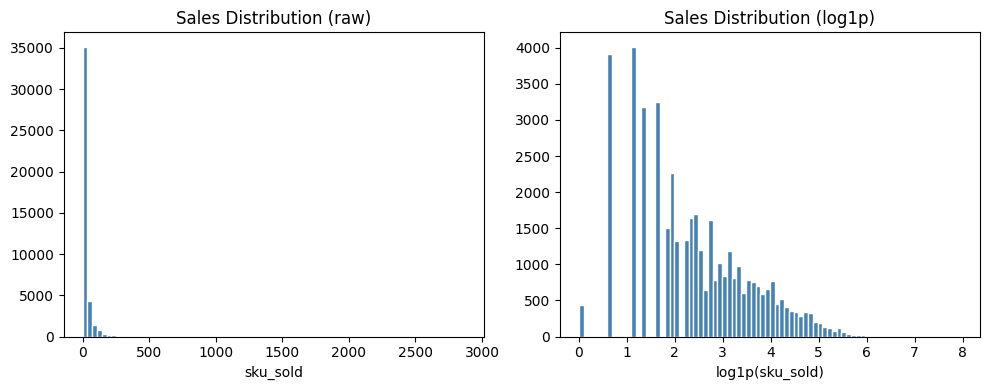

In [19]:
print("sku_sold distribution:")
print(df_clean['sku_sold'].quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99, 1.0]))

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df_clean['sku_sold'], bins=80, color='steelblue', edgecolor='white')
plt.title('Sales Distribution (raw)')
plt.xlabel('sku_sold')

plt.subplot(1, 2, 2)
plt.hist(np.log1p(df_clean['sku_sold']), bins=80, color='steelblue', edgecolor='white')
plt.title('Sales Distribution (log1p)')
plt.xlabel('log1p(sku_sold)')

plt.tight_layout()
plt.show()

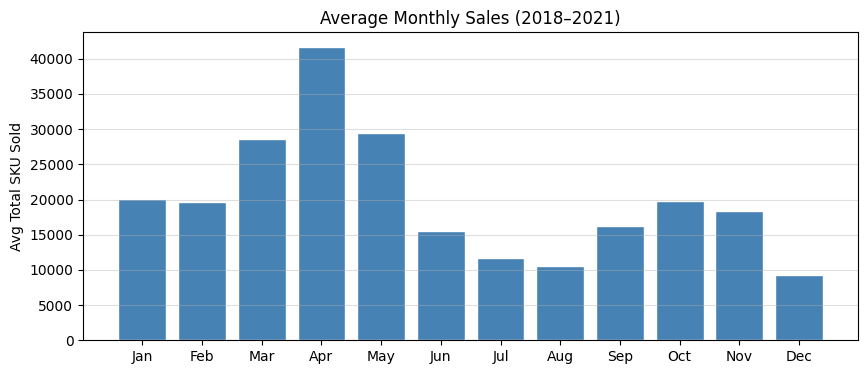

In [20]:
monthly = df_clean.groupby(['year', 'month'])['sku_sold'].sum().reset_index()
month_avg = monthly.groupby('month')['sku_sold'].mean()
month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

plt.figure(figsize=(10, 4))
plt.bar(month_names, month_avg.values, color='steelblue', edgecolor='white')
plt.title('Average Monthly Sales (2018–2021)')
plt.ylabel('Avg Total SKU Sold')
plt.grid(axis='y', alpha=0.4)
plt.show()

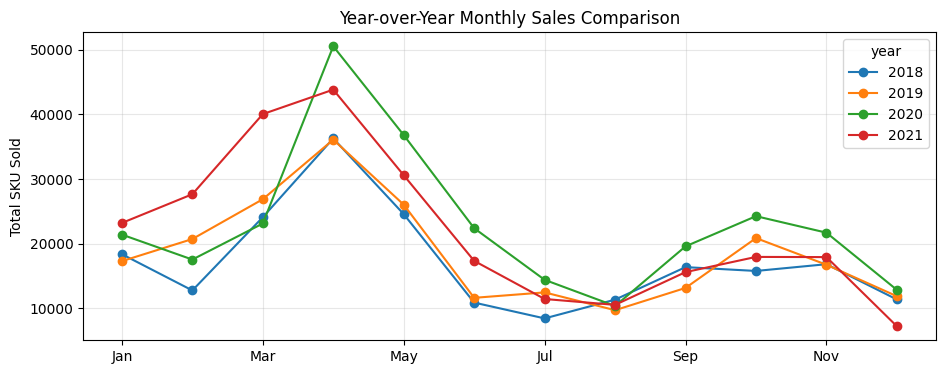

April sales by year:
year
2018    36281
2019    36088
2020    50519
2021    43818
Name: sku_sold, dtype: int64


In [21]:
monthly_pivot = monthly[monthly['year'] >= 2018].pivot(
    index='month', columns='year', values='sku_sold'
)

monthly_pivot.index = month_names
monthly_pivot.plot(figsize=(11, 4), marker='o')
plt.title('Year-over-Year Monthly Sales Comparison')
plt.ylabel('Total SKU Sold')
plt.xlabel('')
plt.grid(alpha=0.3)
plt.show()

# 2020 April 
print("April sales by year:")
print(monthly[monthly['month'] == 4].set_index('year')['sku_sold'])

Top 10 products account for 38.1% of total sales

Top 10 products:
 product_id
7      91516
8      61527
42     36935
11     32228
2      29778
21     29510
32     29303
17     22190
514    19087
511    18261
Name: sku_sold, dtype: int64


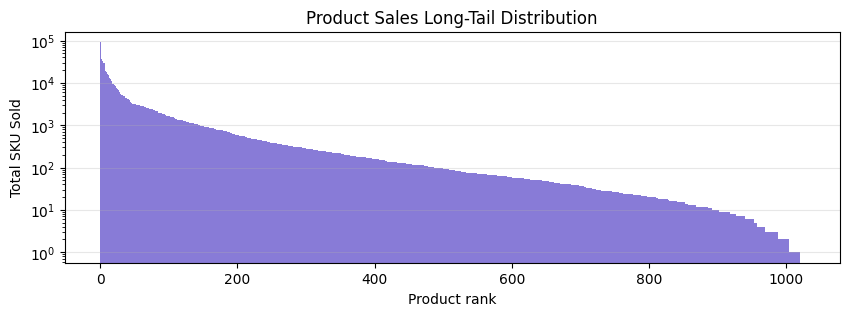

In [22]:
product_totals = df_clean.groupby('product_id')['sku_sold'].sum().sort_values(ascending=False)
top10_pct = product_totals.head(10).sum() / product_totals.sum() * 100

print(f"Top 10 products account for {top10_pct:.1f}% of total sales")
print("\nTop 10 products:\n", product_totals.head(10))

plt.figure(figsize=(10, 3))
plt.bar(range(len(product_totals)), product_totals.values, width=1.0, color='slateblue', alpha=0.8)
plt.title('Product Sales Long-Tail Distribution')
plt.xlabel('Product rank')
plt.ylabel('Total SKU Sold')
plt.yscale('log')
plt.grid(axis='y', alpha=0.3)
plt.show()

In [23]:
df_clean.to_csv("sales_preprocessed_daily.csv", index=False)

weekly.to_csv("sales_preprocessed_weekly.csv", index=False)

df_model.to_csv("sales_preprocessed_weekly_model.csv", index=False)

print("Saved 3 files.")
print("  sales_preprocessed_daily.csv      →", len(df_clean), "rows")
print("  sales_preprocessed_weekly.csv     →", len(weekly), "rows")
print("  sales_preprocessed_weekly_model.csv →", len(df_model), "rows")

Saved 3 files.
  sales_preprocessed_daily.csv      → 42571 rows
  sales_preprocessed_weekly.csv     → 19732 rows
  sales_preprocessed_weekly_model.csv → 13579 rows


In [24]:
product_stats = (
    df_model.groupby('product_id')['sku_sold']
    .agg(
        total_sales   = 'sum',
        mean_weekly   = 'mean',
        median_weekly = 'median',
        std_weekly    = 'std',
        weeks_active  = 'count',
        max_week      = 'max',
        min_week      = 'min',
    )
    .reset_index()
)
# cv = std / mean
product_stats['cv'] = product_stats['std_weekly'] / product_stats['mean_weekly']

product_stats['sales_rank'] = product_stats['total_sales'].rank(ascending=False).astype(int)

product_stats = product_stats.sort_values('total_sales', ascending=False).reset_index(drop=True)
print(product_stats.head(20))

    product_id  total_sales  mean_weekly  median_weekly  std_weekly  \
0            7        91516   437.875598          395.0  280.936113   
1            8        61527   294.387560          235.0  189.910323   
2           42        36935   178.429952          136.0  167.957154   
3           11        32228   154.942308           90.5  159.435982   
4            2        29778   275.722222          171.0  246.154455   
5           21        29510   142.560386           98.0  126.248080   
6           32        29303   140.205742           92.0  141.933018   
7           17        22190   125.367232           75.0  124.759658   
8          514        19087   152.696000           71.0  205.040957   
9          511        18261   138.340909           82.5  149.606243   
10          68        16797   107.673077           84.5   85.100484   
11          40        16565    83.241206           57.0   76.116153   
12          44        15257    76.285000           61.5   74.778291   
13    

In [25]:
TOP_N = 15

top_products = product_stats.head(TOP_N).copy()
top_ids = top_products['product_id'].tolist()

print(f"Top {TOP_N} products by total sales:")
print(top_products[['product_id','total_sales','mean_weekly','cv','weeks_active','sales_rank']])

Top 15 products by total sales:
    product_id  total_sales  mean_weekly        cv  weeks_active  sales_rank
0            7        91516   437.875598  0.641589           209           1
1            8        61527   294.387560  0.645103           209           2
2           42        36935   178.429952  0.941306           207           3
3           11        32228   154.942308  1.029002           208           4
4            2        29778   275.722222  0.892762           108           5
5           21        29510   142.560386  0.885576           207           6
6           32        29303   140.205742  1.012320           209           7
7           17        22190   125.367232  0.995154           177           8
8          514        19087   152.696000  1.342805           125           9
9          511        18261   138.340909  1.081432           132          10
10          68        16797   107.673077  0.790360           156          11
11          40        16565    83.241206  0.

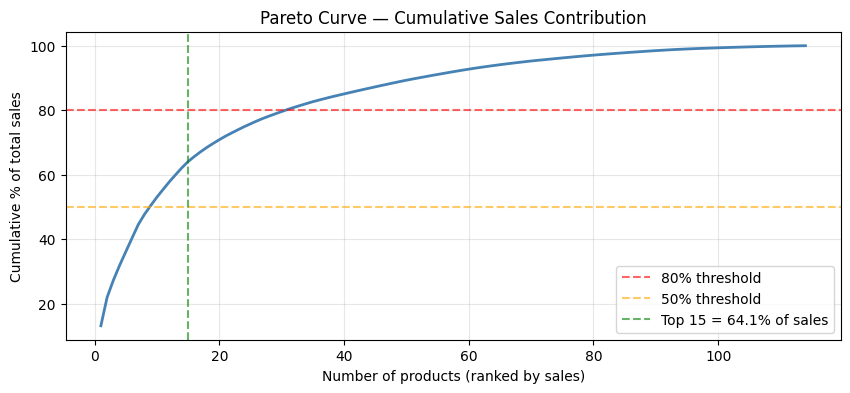

Products needed to cover 80% of total sales: 31


In [26]:
product_stats['cumulative_pct'] = (
    product_stats['total_sales'].cumsum() / product_stats['total_sales'].sum() * 100
)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(product_stats) + 1), product_stats['cumulative_pct'],
         color='steelblue', linewidth=2)
plt.axhline(80, color='red', linestyle='--', alpha=0.6, label='80% threshold')
plt.axhline(50, color='orange', linestyle='--', alpha=0.6, label='50% threshold')

# Top 15
pct_at_top15 = product_stats.loc[TOP_N - 1, 'cumulative_pct']
plt.axvline(TOP_N, color='green', linestyle='--', alpha=0.6,
            label=f'Top {TOP_N} = {pct_at_top15:.1f}% of sales')

plt.xlabel('Number of products (ranked by sales)')
plt.ylabel('Cumulative % of total sales')
plt.title('Pareto Curve — Cumulative Sales Contribution')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# 80% sales
n_for_80 = (product_stats['cumulative_pct'] < 80).sum() + 1
print(f"Products needed to cover 80% of total sales: {n_for_80}")

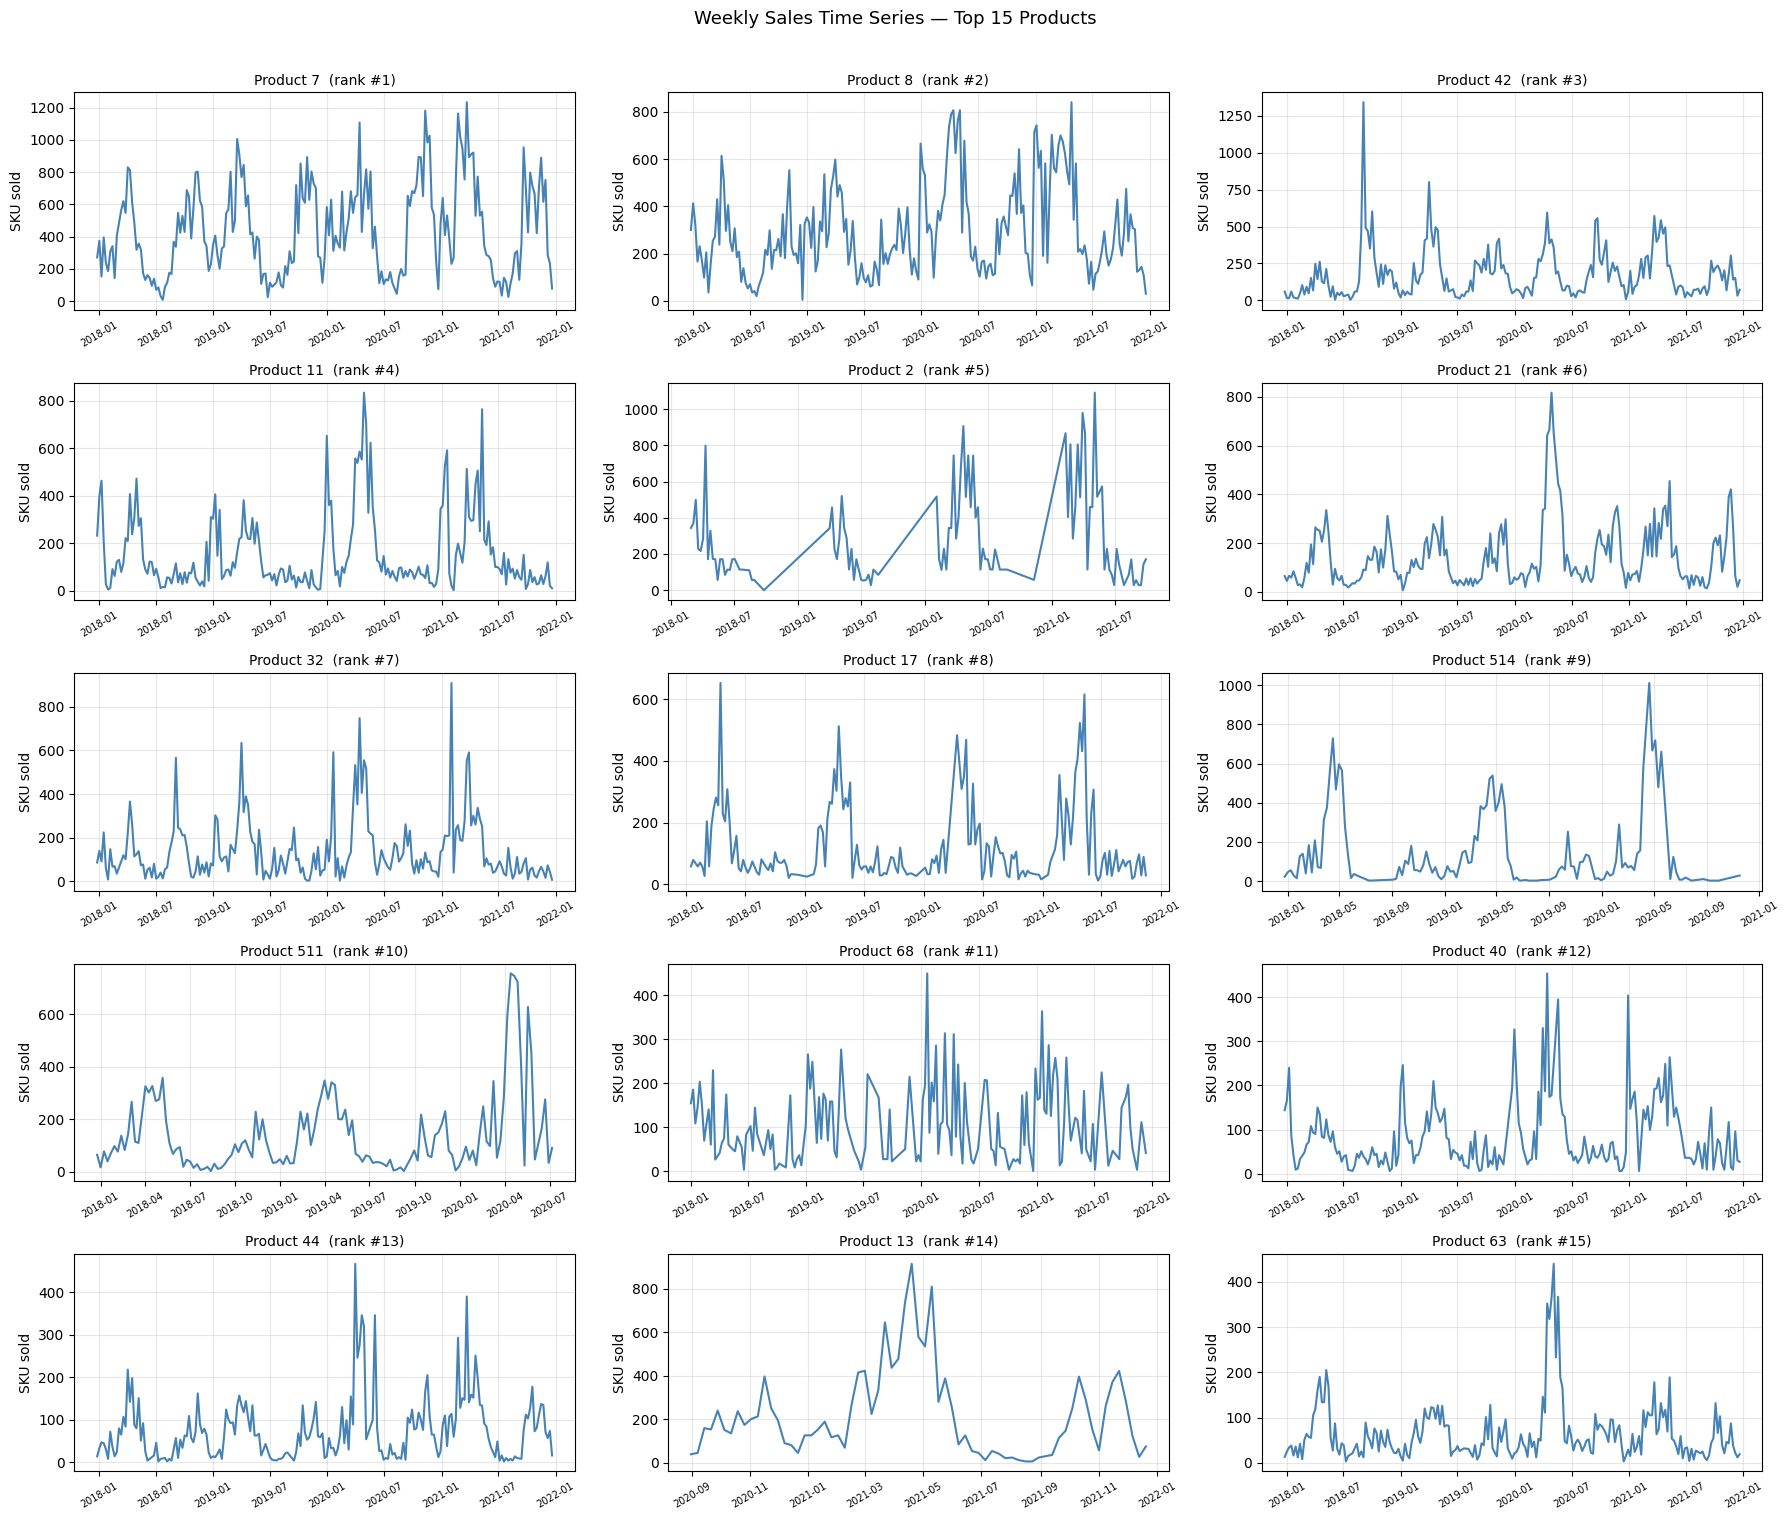

In [27]:
df_top = df_model[df_model['product_id'].isin(top_ids)].copy()
df_top = df_top.sort_values(['product_id', 'week_start'])

n_cols = 3
n_rows = (TOP_N + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 3))
axes = axes.flatten()

for i, pid in enumerate(top_ids):
    ax = axes[i]
    data = df_top[df_top['product_id'] == pid]
    ax.plot(data['week_start'], data['sku_sold'], linewidth=1.5, color='steelblue')
    ax.set_title(f'Product {pid}  (rank #{i+1})', fontsize=10)
    ax.set_xlabel('')
    ax.set_ylabel('SKU sold')
    ax.grid(alpha=0.3)
    ax.tick_params(axis='x', rotation=30, labelsize=7)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(f'Weekly Sales Time Series — Top {TOP_N} Products', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

In [28]:
df_top['month'] = df_top['week_start'].dt.month

seasonality = (
    df_top.groupby(['product_id', 'month'])['sku_sold']
    .mean()
    .reset_index()
)

# hiher CV，higher seasonality
seasonality_strength = (
    seasonality.groupby('product_id')['sku_sold']
    .agg(lambda x: x.std() / x.mean())
    .reset_index()
    .rename(columns={'sku_sold': 'seasonality_strength'})
    .sort_values('seasonality_strength', ascending=False)
)

print("Seasonality strength by product (higher = more seasonal):")
print(seasonality_strength)

Seasonality strength by product (higher = more seasonal):
    product_id  seasonality_strength
14         514              1.311548
13         511              0.889290
4           13              0.869363
5           17              0.852412
3           11              0.758762
0            2              0.720036
11          63              0.694935
10          44              0.681070
9           42              0.664877
6           21              0.658353
7           32              0.631904
8           40              0.605009
1            7              0.524466
12          68              0.475333
2            8              0.438830


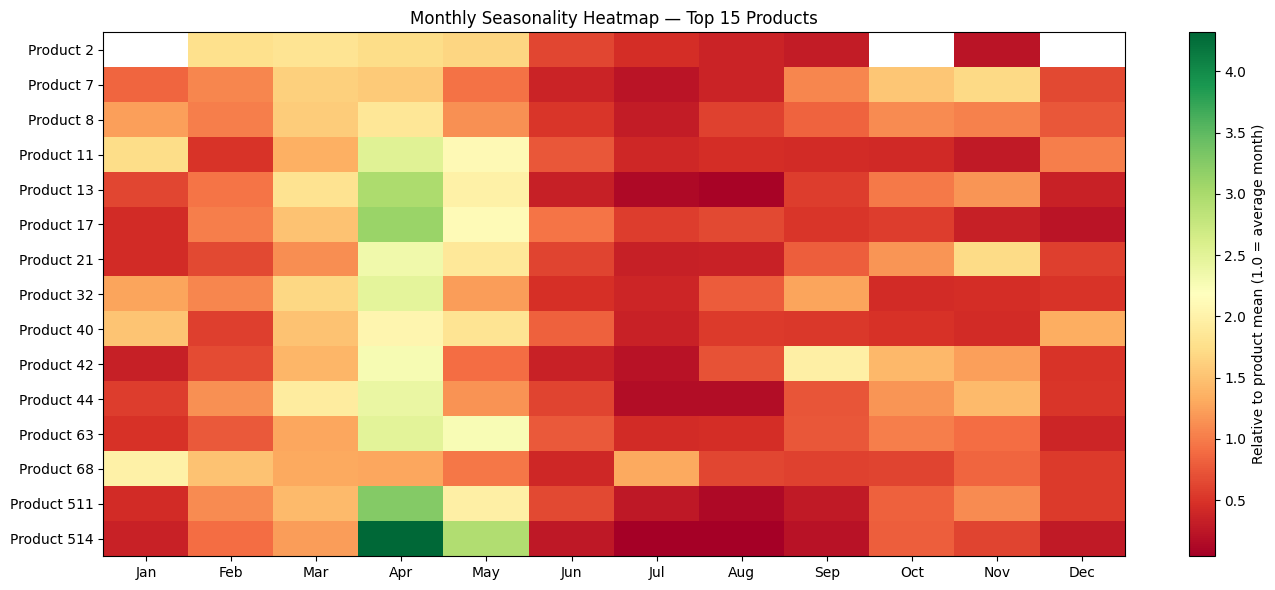

In [29]:
month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

pivot = seasonality.pivot(index='product_id', columns='month', values='sku_sold')
pivot.columns = month_names

pivot_norm = pivot.div(pivot.mean(axis=1), axis=0)

plt.figure(figsize=(14, 6))
im = plt.imshow(pivot_norm.values, aspect='auto', cmap='RdYlGn')
plt.colorbar(im, label='Relative to product mean (1.0 = average month)')
plt.xticks(range(12), month_names)
plt.yticks(range(len(pivot_norm)), [f'Product {p}' for p in pivot_norm.index])
plt.title(f'Monthly Seasonality Heatmap — Top {TOP_N} Products')
plt.tight_layout()
plt.show()

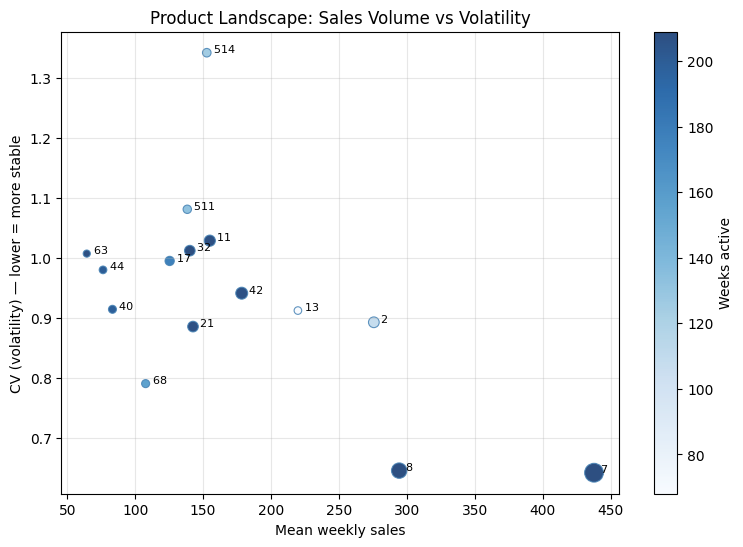

In [30]:
plt.figure(figsize=(9, 6))

sc = plt.scatter(
    top_products['mean_weekly'],
    top_products['cv'],
    s=top_products['total_sales'] / 500,  
    c=top_products['weeks_active'],         
    cmap='Blues', edgecolors='steelblue', linewidths=0.8, alpha=0.85
)

plt.colorbar(sc, label='Weeks active')

for _, row in top_products.iterrows():
    plt.annotate(f"  {int(row['product_id'])}",
                 (row['mean_weekly'], row['cv']), fontsize=8)

plt.xlabel('Mean weekly sales')
plt.ylabel('CV (volatility) — lower = more stable')
plt.title('Product Landscape: Sales Volume vs Volatility')
plt.grid(alpha=0.3)
plt.show()

In [31]:
summary = top_products.merge(seasonality_strength, on='product_id')

summary_out = summary[[
    'sales_rank', 'product_id', 'total_sales', 'mean_weekly',
    'cv', 'seasonality_strength', 'weeks_active'
]].round(3)

print("=== High-Value Product Summary ===")
print(summary_out.to_string(index=False))

=== High-Value Product Summary ===
 sales_rank  product_id  total_sales  mean_weekly    cv  seasonality_strength  weeks_active
          1           7        91516      437.876 0.642                 0.524           209
          2           8        61527      294.388 0.645                 0.439           209
          3          42        36935      178.430 0.941                 0.665           207
          4          11        32228      154.942 1.029                 0.759           208
          5           2        29778      275.722 0.893                 0.720           108
          6          21        29510      142.560 0.886                 0.658           207
          7          32        29303      140.206 1.012                 0.632           209
          8          17        22190      125.367 0.995                 0.852           177
          9         514        19087      152.696 1.343                 1.312           125
         10         511        18261      138